In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys


array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

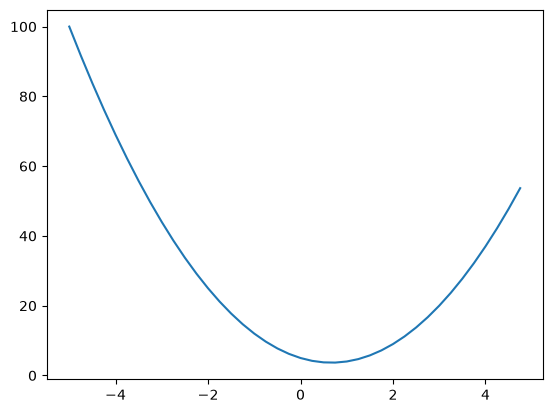

In [5]:
plt.plot(xs, ys)

In [6]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [7]:
#lets get more complax(3 scaler inputs)
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
#derivative of d with respect to a b and c

h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b +c
a += h
d2 = a*b +c
print('d1' , d1)
print('d2' , d2)
print('slope' , (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
#derivative of d with respect to a b and c
#bumping b in a positive direction

h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b +c
b += h
d2 = a*b +c
print('d1' , d1)
print('d2' , d2)
print('slope' , (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [10]:
#derivative of d with respect to a b and c
#bumping c in a positive direction

h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b +c
c += h
d2 = a*b +c
print('d1' , d1)
print('d2' , d2)
print('slope' , (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [11]:
#value object skelton
# class Value:

#     def __init__(self, data):
#         self.data = data

#     def __repr__(self):
#         return f"value(data={self.data})"

# a = Value(2.0)
# a

In [12]:
#value object skelton
#to add 2 values
# class Value:

#     def __init__(self, data):
#         self.data = data

#     def __repr__(self):
#         return f"value(data={self.data})"

#     def __add__(self, other):
#         out = Value(self.data +other.data)
#         return out

# a = Value(2.0)
# b = Value(-3.0)
# a +b

In [13]:
#value object skelton
#to multiply 2 values
# class Value:

#     def __init__(self, data):
#         self.data = data

#     def __repr__(self):
#         return f"value(data={self.data})"

#     def __add__(self, other):
#         out = Value(self.data + other.data)
#         return out

#     def __mul__(self, other):
#         out = Value(self.data * other.data)
#         return out

# a = Value(2.0)
# b = Value(-3.0)
# c = Value(10.0)
# a * b

In [14]:
#value object skelton
#to multiply 2 values
# class Value:

#     def __init__(self, data):
#         self.data = data

#     def __repr__(self):
#         return f"value(data={self.data})"

#     def __add__(self, other):
#         out = Value(self.data + other.data)
#         return out

#     def __mul__(self, other):
#         out = Value(self.data * other.data)
#         return out

# a = Value(2.0)
# b = Value(-3.0)
# c = Value(10.0)
# a * b + c

In [15]:
#to see what values produce what values
#we will introduct new children variable

class Value:

    def __init__(self, data, _children= (), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op= _op
        self.label = label

    def __repr__(self):
        return f"value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label ='a')
b = Value(-3.0, label ='b')
c = Value(10.0, label ='c')
e = a*b; e.label ='e'
d = e + c; d.label ='d'
f = Value(-2.0, label='f')
L = d *f; L.label ='L'
L

value(data=-8.0)

In [16]:
d._prev


{value(data=-6.0), value(data=10.0)}

In [17]:
d._op

'+'

In [18]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = Left to Right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f }" % (n.label, n.data),
            shape='record'
        )

        # if this value is a result of some operation, create an op node for it
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

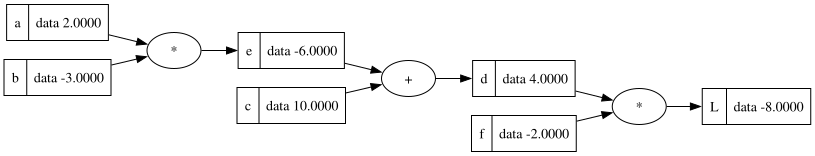

In [19]:
draw_dot(L)

**Quick Recape on what we have done so far..**
we are able to build ut mathematical expression using only plus and times so far..
they are scaler values on the way and we can do tis forward pass and build out a mathematical expression.

we have multiple inputs here a, b,c, and f, going into mathematical expression that produces a single output L.

The graph above is vsualizing forward pass.

The output of the frward pass is value -8.0000.

**what we do next is:**
we would run backpropagation.
In backpropagation we are going to start from the end L value and we are going to reverse and calculate the gradient along all the intermediate values in graph.
we are computing for every single value. we are going to compute derivative of that node with respect to L.

such as derivative with respect to L with L is just 1, than we are going to derive what is the derivative of L with respect to F, d, c, e, b and a.
And in neural network settings you would be very intrested in derivative of basically this loss function L with respect to weights of the neural networks and here of course we have just these varaibales a b c and f but some of these will eventually represent the weights of the neural net, and so we will need to know how these wights are impacting the loss finction.

We will be basically intrested in the derivative of the output with respect to some of its leaf nodes and those leaf nodes will be the weights of the neural net and the other leaf nodes will be the data itself, but usually we will not want or need to use the derivative of the loss function with  respect  to data  beacause the data is fixed but the weights will be iterated on using the gardient information.



In [20]:
#creating a variable inside value clasue that maintaine the derivaltive of l wth repect to that value(grad variable)

#initialy it will be 0, which means no effect,so at initailization we are assuming that every value does not impact the output.
#when gradient is 0 that means changing this vairiable is not changing yhe loss function.

class Value:

    def __init__(self, data, _children= (), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op= _op
        self.label = label

    def __repr__(self):
        return f"value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label ='a')
b = Value(-3.0, label ='b')
c = Value(10.0, label ='c')
e = a*b; e.label ='e'
d = e + c; d.label ='d'
f = Value(-2.0, label='f')
L = d *f; L.label ='L'
L

value(data=-8.0)

In [21]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = Left to Right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | gard %.4f}" % (n.label, n.data, n.grad),
            shape='record'
        )

        # if this value is a result of some operation, create an op node for it
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

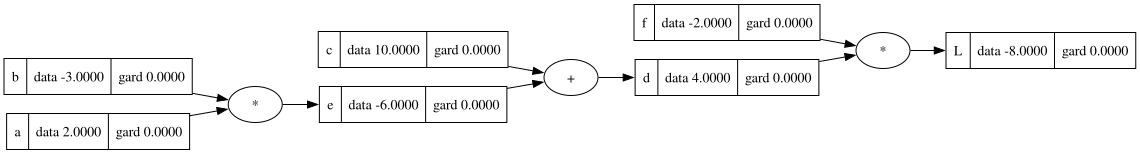

In [22]:
#Initialized at gradient 0.
draw_dot(L)


Now we will fill in these gradients and doing backpropagation manually.

In [23]:
L.grad = 1.0

In [24]:
def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data + h

    print((L2 - L1)/h)

lol()


1.000000000000334


**#l with respect to d**

**L = d*f**

**dL/dd = ? = f**

lets prove how its equal to f?

lets drive it

#defination of Deriactive is:

(f(x+h)-f(x))/h

((d+h)*f - d*f)/h

(d*f +h*f - d*f) / h

(h*f)/h

f

#hence proved


In [25]:
#set manually
f.grad = 4.0
d.grad = -2

In [26]:
#lets verify this (l with respect to f)

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0 + h, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

3.9999999999995595


In [27]:
#lets verify this (l with respect to d)

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    d.data += h
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-2.000000000000668


what we did above is called gradient check.
**Gradient checking is a debugging tool used to verify that the backpropagation code in a neural network is working right.**

inline gradient check: when we are driving this like backpropagation and getting derivative with respect to all the intermiediate results

numerical gradient check: is estimating it using small step size.

In [28]:
#CRUX of Backpropagation if you understand this you understand all backpropagaation all nurat networks.


#derivative of d with resppect to c

dd/dc ? 1.0

d = c+e

(f(x+h) - f(x)) / h

((c+ h + e) - (c + e))/h

h/h

1.0


dd/de = 1.0

(f(x+h) - f(x)) / h

e = a*b

((a+h)*b - (a*b))/h

(a*b - h*b - a*b)/h

h*b/h

b

In [31]:
c.grad = -2.0
e.grad = -2.0

In [37]:
#lets verify this (l with respect to c)

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    c.data += h
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()
   

-1.9999999999988916


In [38]:
#lets verify this (l with respect to e)

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    e.data += h
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-2.000000000000668


#backpropagtaion now towards a and b

dl / de = -2.0

e = a * b
de /da ? b

dl / da = (dl / de)* (de / da)

In [39]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

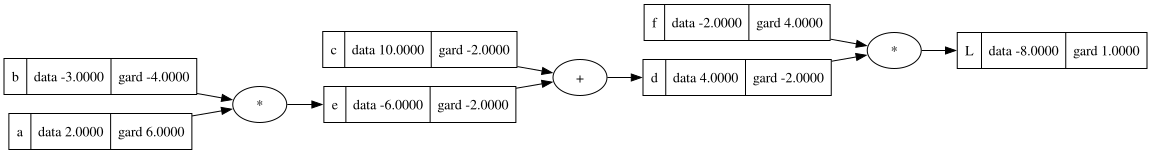

In [40]:
#Initialized at gradient 0.
draw_dot(L)

In [41]:
#lets verify this a

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    a.data += h
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

6.000000000000227


In [42]:
#lets verify this b

def lol():
    h =0.001
    
    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L1 = L.data

    a = Value(2.0, label ='a')
    b = Value(-3.0, label ='b')
    b.data += h
    c = Value(10.0, label ='c')
    e = a*b; e.label ='e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label='f')
    L = d *f; L.label ='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-3.9999999999995595
